# Revisão de Spark

## Instalação dos recursos necessários

In [20]:
!pip install pyspark

## Importação dos modulos

In [21]:


from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType
from pyspark.sql.functions import *
from pyspark.sql.types import *



## Inicialização da Session

In [22]:
from pyspark.sql import SparkSession

# Criando uma sessão Spark
spark = SparkSession.builder \
    .appName("IntroducaoSpark") \
    .config("spark.ui.port", "4050") \
    .getOrCreate()

# Verificando a versão do Spark
print(f"Versão do Spark: {spark.version}")

Versão do Spark: 3.5.1


In [3]:
path = "/content/sales.csv"

## Lendo o arquivo

In [9]:
dados_Vendas = spark.read(path, header=True, inferSchema=True)

## Verificar a estrutura do arquivo

In [10]:
print("Schema do DataFrame:")
dados_Vendas.printSchema()

Schema do DataFrame:
root
 |-- Data: date (nullable = true)
 |-- ID_Cliente: string (nullable = true)
 |-- Nome_Cliente: string (nullable = true)
 |-- ID_Vendedor: string (nullable = true)
 |-- Nome_Vendedor: string (nullable = true)
 |-- Cidade: string (nullable = true)
 |-- Estado: string (nullable = true)
 |-- Categoria_Produto: string (nullable = true)
 |-- Produto: string (nullable = true)
 |-- Quantidade: integer (nullable = true)
 |-- Preco_Unitario: integer (nullable = true)
 |-- Desconto: double (nullable = true)
 |-- Valor_Total: double (nullable = true)
 |-- Custo: integer (nullable = true)
 |-- Lucro: double (nullable = true)
 |-- Metodo_Envio: string (nullable = true)
 |-- Frequencia_Compra: integer (nullable = true)



## Outra forma de criar um DataFrame

In [11]:
dados = [
    ("valor1","Valor2","Valor3"),
    ("valor4","Valor5","Valor6"),
    ("valor7","Valor8","Valor9")

]

schema = StructType([
    StructField("coluna1", StringType(), True),
    StructField("coluna2", StringType(), True),
    StructField("coluna3", StringType(), True)
])

df = spark.createDataFrame(dados, schema)

df.show()

+-------+-------+-------+
|coluna1|coluna2|coluna3|
+-------+-------+-------+
| valor1| Valor2| Valor3|
| valor4| Valor5| Valor6|
| valor7| Valor8| Valor9|
+-------+-------+-------+



In [13]:
dados_Vendas.show(5)
dados_Vendas.count()

+----------+----------+---------------+-----------+-------------+--------------+------+-----------------+------------+----------+--------------+--------+-----------+-----+-----+------------+-----------------+
|      Data|ID_Cliente|   Nome_Cliente|ID_Vendedor|Nome_Vendedor|        Cidade|Estado|Categoria_Produto|     Produto|Quantidade|Preco_Unitario|Desconto|Valor_Total|Custo|Lucro|Metodo_Envio|Frequencia_Compra|
+----------+----------+---------------+-----------+-------------+--------------+------+-----------------+------------+----------+--------------+--------+-----------+-----+-----+------------+-----------------+
|2023-01-05|      C001|     João Silva|       V001| Ana Oliveira|     São Paulo|    SP|      Eletrônicos|  Smartphone|         2|          1200|    0.05|     2280.0| 1800|480.0|    Expresso|                3|
|2023-01-10|      C002|   Maria Santos|       V002|  Bruno Costa|Rio de Janeiro|    RJ|           Móveis|        Sofá|         1|          2500|     0.1|     2250.0

50

## Selecionar Dados

In [31]:
dados_vendas_diarias = dados_Vendas.select("Data","Valor_Total","Custo","Lucro")
dados_vendas_diarias.show()

+----------+-----------+-----+-----+
|      Data|Valor_Total|Custo|Lucro|
+----------+-----------+-----+-----+
|2023-01-05|     2280.0| 1800|480.0|
|2023-01-10|     2250.0| 1800|450.0|
|2023-01-15|     3500.0| 2800|700.0|
|2023-01-20|      212.5|  125| 87.5|
|2023-01-25|      360.0|  280| 80.0|
|2023-02-03|      342.0|  240|102.0|
|2023-02-08|      720.0|  550|170.0|
|2023-02-12|     2090.0| 1700|390.0|
|2023-02-18|      360.0|  210|150.0|
|2023-02-25|       76.0|   40| 36.0|
|2023-03-02|     1350.0| 1100|250.0|
|2023-03-07|      600.0|  400|200.0|
|2023-03-15|     1530.0| 1200|330.0|
|2023-03-20|      342.0|  200|142.0|
|2023-03-28|      270.0|  180| 90.0|
|2023-04-05|      540.0|  400|140.0|
|2023-04-10|     1140.0|  900|240.0|
|2023-04-18|     1600.0| 1200|400.0|
|2023-04-22|      225.0|  150| 75.0|
|2023-04-30|      125.0|   75| 50.0|
+----------+-----------+-----+-----+
only showing top 20 rows



## Ordenação com PySpark

In [32]:
dados_vendas_diarias.orderBy(col("Data").desc()).show(5)

+----------+-----------+-----+-----+
|      Data|Valor_Total|Custo|Lucro|
+----------+-----------+-----+-----+
|2023-10-28|      114.0|   75| 39.0|
|2023-10-22|      378.0|  240|138.0|
|2023-10-16|     2470.0| 2000|470.0|
|2023-10-10|      950.0|  700|250.0|
|2023-10-04|     3315.0| 3000|315.0|
+----------+-----------+-----+-----+
only showing top 5 rows



## Criando uma nova coluna com a margem de lucro


In [41]:
vendas_com_margem_lucro = dados_vendas_diarias.withColumn("Margem_Lucro", round( (col("Lucro") / col("Valor_Total")) * 100,2))
vendas_com_margem_lucro.show()


+----------+-----------+-----+-----+------------+
|      Data|Valor_Total|Custo|Lucro|Margem_Lucro|
+----------+-----------+-----+-----+------------+
|2023-01-05|     2280.0| 1800|480.0|       21.05|
|2023-01-10|     2250.0| 1800|450.0|        20.0|
|2023-01-15|     3500.0| 2800|700.0|        20.0|
|2023-01-20|      212.5|  125| 87.5|       41.18|
|2023-01-25|      360.0|  280| 80.0|       22.22|
|2023-02-03|      342.0|  240|102.0|       29.82|
|2023-02-08|      720.0|  550|170.0|       23.61|
|2023-02-12|     2090.0| 1700|390.0|       18.66|
|2023-02-18|      360.0|  210|150.0|       41.67|
|2023-02-25|       76.0|   40| 36.0|       47.37|
|2023-03-02|     1350.0| 1100|250.0|       18.52|
|2023-03-07|      600.0|  400|200.0|       33.33|
|2023-03-15|     1530.0| 1200|330.0|       21.57|
|2023-03-20|      342.0|  200|142.0|       41.52|
|2023-03-28|      270.0|  180| 90.0|       33.33|
|2023-04-05|      540.0|  400|140.0|       25.93|
|2023-04-10|     1140.0|  900|240.0|       21.05|


## Verificando o dia com maior margem de lucro

In [42]:
vendas_com_margem_lucro.orderBy(col("Margem_Lucro").desc()).show()

+----------+-----------+-----+-----+------------+
|      Data|Valor_Total|Custo|Lucro|Margem_Lucro|
+----------+-----------+-----+-----+------------+
|2023-02-25|       76.0|   40| 36.0|       47.37|
|2023-02-18|      360.0|  210|150.0|       41.67|
|2023-03-20|      342.0|  200|142.0|       41.52|
|2023-01-20|      212.5|  125| 87.5|       41.18|
|2023-09-18|      351.0|  210|141.0|       40.17|
|2023-04-30|      125.0|   75| 50.0|        40.0|
|2023-07-30|       80.0|   48| 32.0|        40.0|
|2023-09-30|      159.6|   96| 63.6|       39.85|
|2023-07-25|      180.0|  110| 70.0|       38.89|
|2023-06-28|      114.0|   70| 44.0|        38.6|
|2023-06-22|      260.0|  160|100.0|       38.46|
|2023-10-22|      378.0|  240|138.0|       36.51|
|2023-05-30|       70.0|   45| 25.0|       35.71|
|2023-09-25|      340.0|  220|120.0|       35.29|
|2023-08-10|      306.0|  200|106.0|       34.64|
|2023-05-25|      228.0|  150| 78.0|       34.21|
|2023-10-28|      114.0|   75| 39.0|       34.21|


## Filtrar Dados

In [18]:
vendas_eletronicos= dados_Vendas.filter(dados_Vendas["Categoria_Produto"] == "Eletrônicos")
vendas_eletronicos.show()

+----------+----------+----------------+-----------+--------------+--------------+------+-----------------+--------------+----------+--------------+--------+-----------+-----+-----+------------+-----------------+
|      Data|ID_Cliente|    Nome_Cliente|ID_Vendedor| Nome_Vendedor|        Cidade|Estado|Categoria_Produto|       Produto|Quantidade|Preco_Unitario|Desconto|Valor_Total|Custo|Lucro|Metodo_Envio|Frequencia_Compra|
+----------+----------+----------------+-----------+--------------+--------------+------+-----------------+--------------+----------+--------------+--------+-----------+-----+-----+------------+-----------------+
|2023-01-05|      C001|      João Silva|       V001|  Ana Oliveira|     São Paulo|    SP|      Eletrônicos|    Smartphone|         2|          1200|    0.05|     2280.0| 1800|480.0|    Expresso|                3|
|2023-01-15|      C003|   Pedro Almeida|       V003|   Carla Souza|Belo Horizonte|    MG|      Eletrônicos|      Notebook|         1|          3500|

## Agrupar Dados

In [48]:
vendas_eletronicos_ordenados = vendas_eletronicos.groupBy("Data") \
                  .agg(sum("Valor_Total").alias("Total_Vendas_Eletronicos")) \
                  .orderBy(col("Total_Vendas_Eletronicos").desc()) \

vendas_eletronicos_ordenados.show()

+----------+------------------------+
|      Data|Total_Vendas_Eletronicos|
+----------+------------------------+
|2023-01-15|                  3500.0|
|2023-06-03|                  3420.0|
|2023-10-04|                  3315.0|
|2023-10-16|                  2470.0|
|2023-01-05|                  2280.0|
|2023-06-15|                  2125.0|
|2023-02-12|                  2090.0|
|2023-07-18|                  1805.0|
|2023-04-18|                  1600.0|
|2023-03-15|                  1530.0|
|2023-07-05|                  1440.0|
|2023-03-02|                  1350.0|
|2023-08-04|                  1282.5|
|2023-05-05|                  1235.0|
|2023-08-16|                   850.0|
|2023-09-05|                   650.0|
|2023-04-05|                   540.0|
|2023-09-18|                   351.0|
|2023-02-03|                   342.0|
|2023-05-18|                   300.0|
+----------+------------------------+



## transformando  a coluna Total_Vendas_Eletronicos em Float

In [56]:
vendas_eletronicos_ordenados = vendas_eletronicos.groupBy("Data") \
                  .agg(sum("Valor_Total").alias("Total_Vendas_Eletronicos")) \
                  .withColumn("Total_Vendas_Eletronicos", col("Total_Vendas_Eletronicos").cast(FloatType())) \
                  .orderBy(col("Total_Vendas_Eletronicos").desc()) \

vendas_eletronicos_ordenados.printSchema()

root
 |-- Data: date (nullable = true)
 |-- Total_Vendas_Eletronicos: float (nullable = true)



## Gerar um Grafico com os dados

### Total de vendas por dia

In [49]:
import matplotlib.pyplot as plt

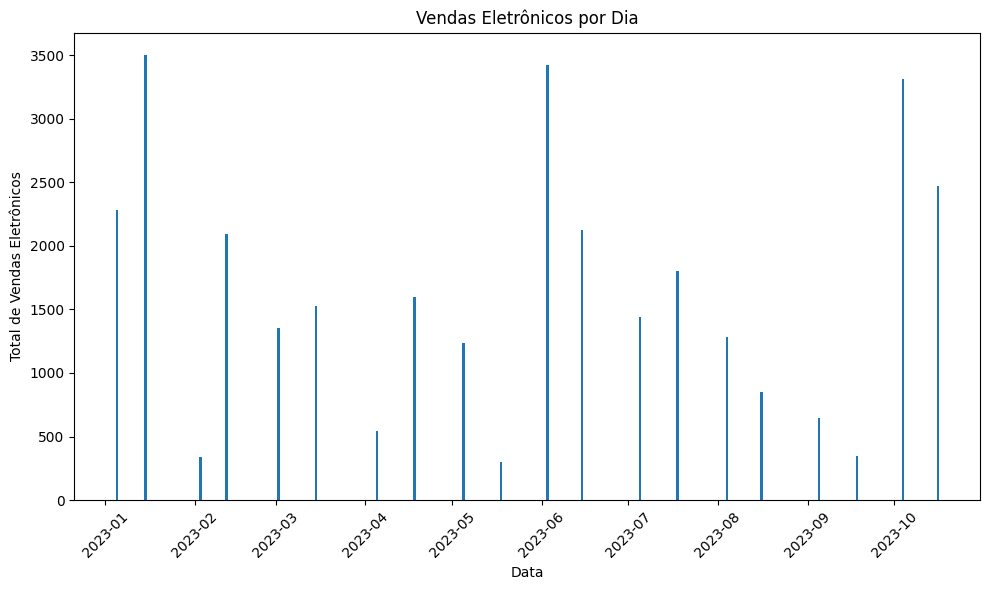

In [71]:
# Coleta os dados do DataFrame para o driver como uma lista de Row
dados = vendas_eletronicos_ordenados.select("Data", "Total_Vendas_Eletronicos").collect()

# Extrai os valores
datas = [row["Data"] for row in dados]
totais = [row["Total_Vendas_Eletronicos"] for row in dados]

# Plotagem com Matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(datas, totais)
plt.xlabel("Data")
plt.ylabel("Total de Vendas Eletrônicos")
plt.title("Vendas Eletrônicos por Dia")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [78]:
vendas_eletronicos_ordenados.printSchema()

root
 |-- Data: date (nullable = true)
 |-- Total_Vendas_Eletronicos: float (nullable = true)



In [80]:
vendas_eletronicos_por_mes = vendas_eletronicos_ordenados.groupBy(month("Data").alias("Mes")) \
                  .agg(sum("Total_Vendas_Eletronicos").alias("Total_Mes")) \
                  .withColumn("Total_Mes", col("Total_Mes").cast(FloatType())) \
                  .orderBy(col("Mes"))


vendas_eletronicos_por_mes.show()


+---+---------+
|Mes|Total_Mes|
+---+---------+
|  1|   5780.0|
|  2|   2432.0|
|  3|   2880.0|
|  4|   2140.0|
|  5|   1535.0|
|  6|   5545.0|
|  7|   3245.0|
|  8|   2132.5|
|  9|   1001.0|
| 10|   5785.0|
+---+---------+



### Total por Mes

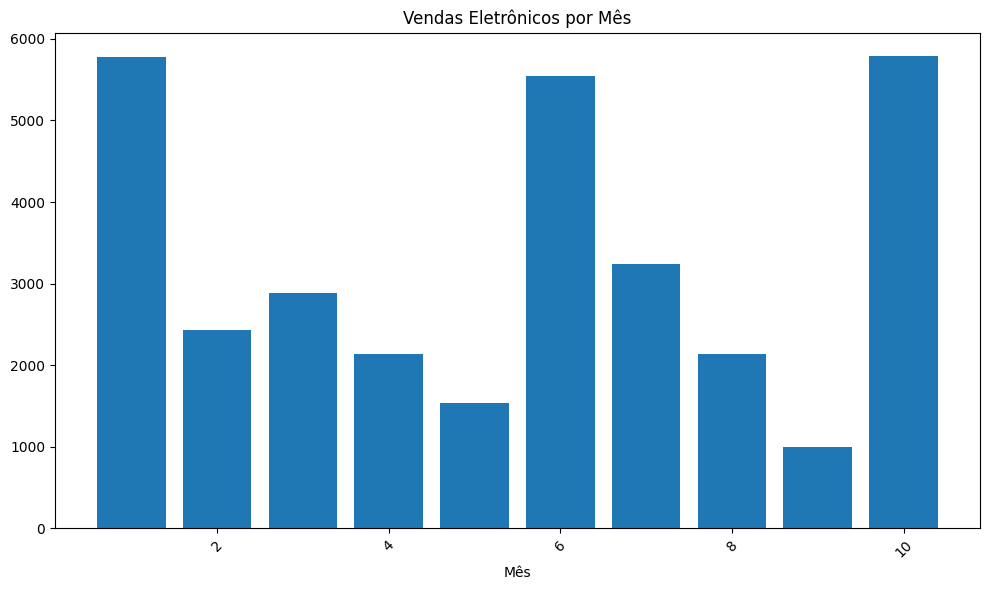

In [82]:
# Coleta os dados do DataFrame para o driver como uma lista de Row
dados = vendas_eletronicos_por_mes.select("Mes", "Total_Mes").collect()

# Extrai os valores
datas = [row["Mes"] for row in dados]
totais = [row["Total_Mes"] for row in dados]

# Plotagem com Matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(datas, totais)
plt.xlabel("Mês")
# plt.ylabel("Total de Vendas Eletrônicos")
plt.title("Vendas Eletrônicos por Mês")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Lista de exercicios pre-prova

### 1. Total de vendas por estado

In [ ]:
# Adicione seu codigo aqui

In [ ]:
# Crie seu Grafico Aqui

### 2. Total de vendas por Vendedor

In [ ]:
# Adicione seu codigo aqui

In [ ]:
# Crie seu Grafico Aqui

### 3. Selecione os Vendedores unicos (eu quero saber quais são os vendedores sem repetição )

In [ ]:
# Adicione seu codigo aqui

### 4. Total do Lucro por Cidade

In [ ]:
# Adicione seu codigo aqui

In [ ]:
# Adicione seu grafico

### 5. Total do Lucro e Média, por Categoria e Metodo de Envio

In [83]:
# Adicione seu codigo aqui
# Agrupar as duas colunas

In [ ]:
# Adicione seu grafico